Saved → ner_comparison.png


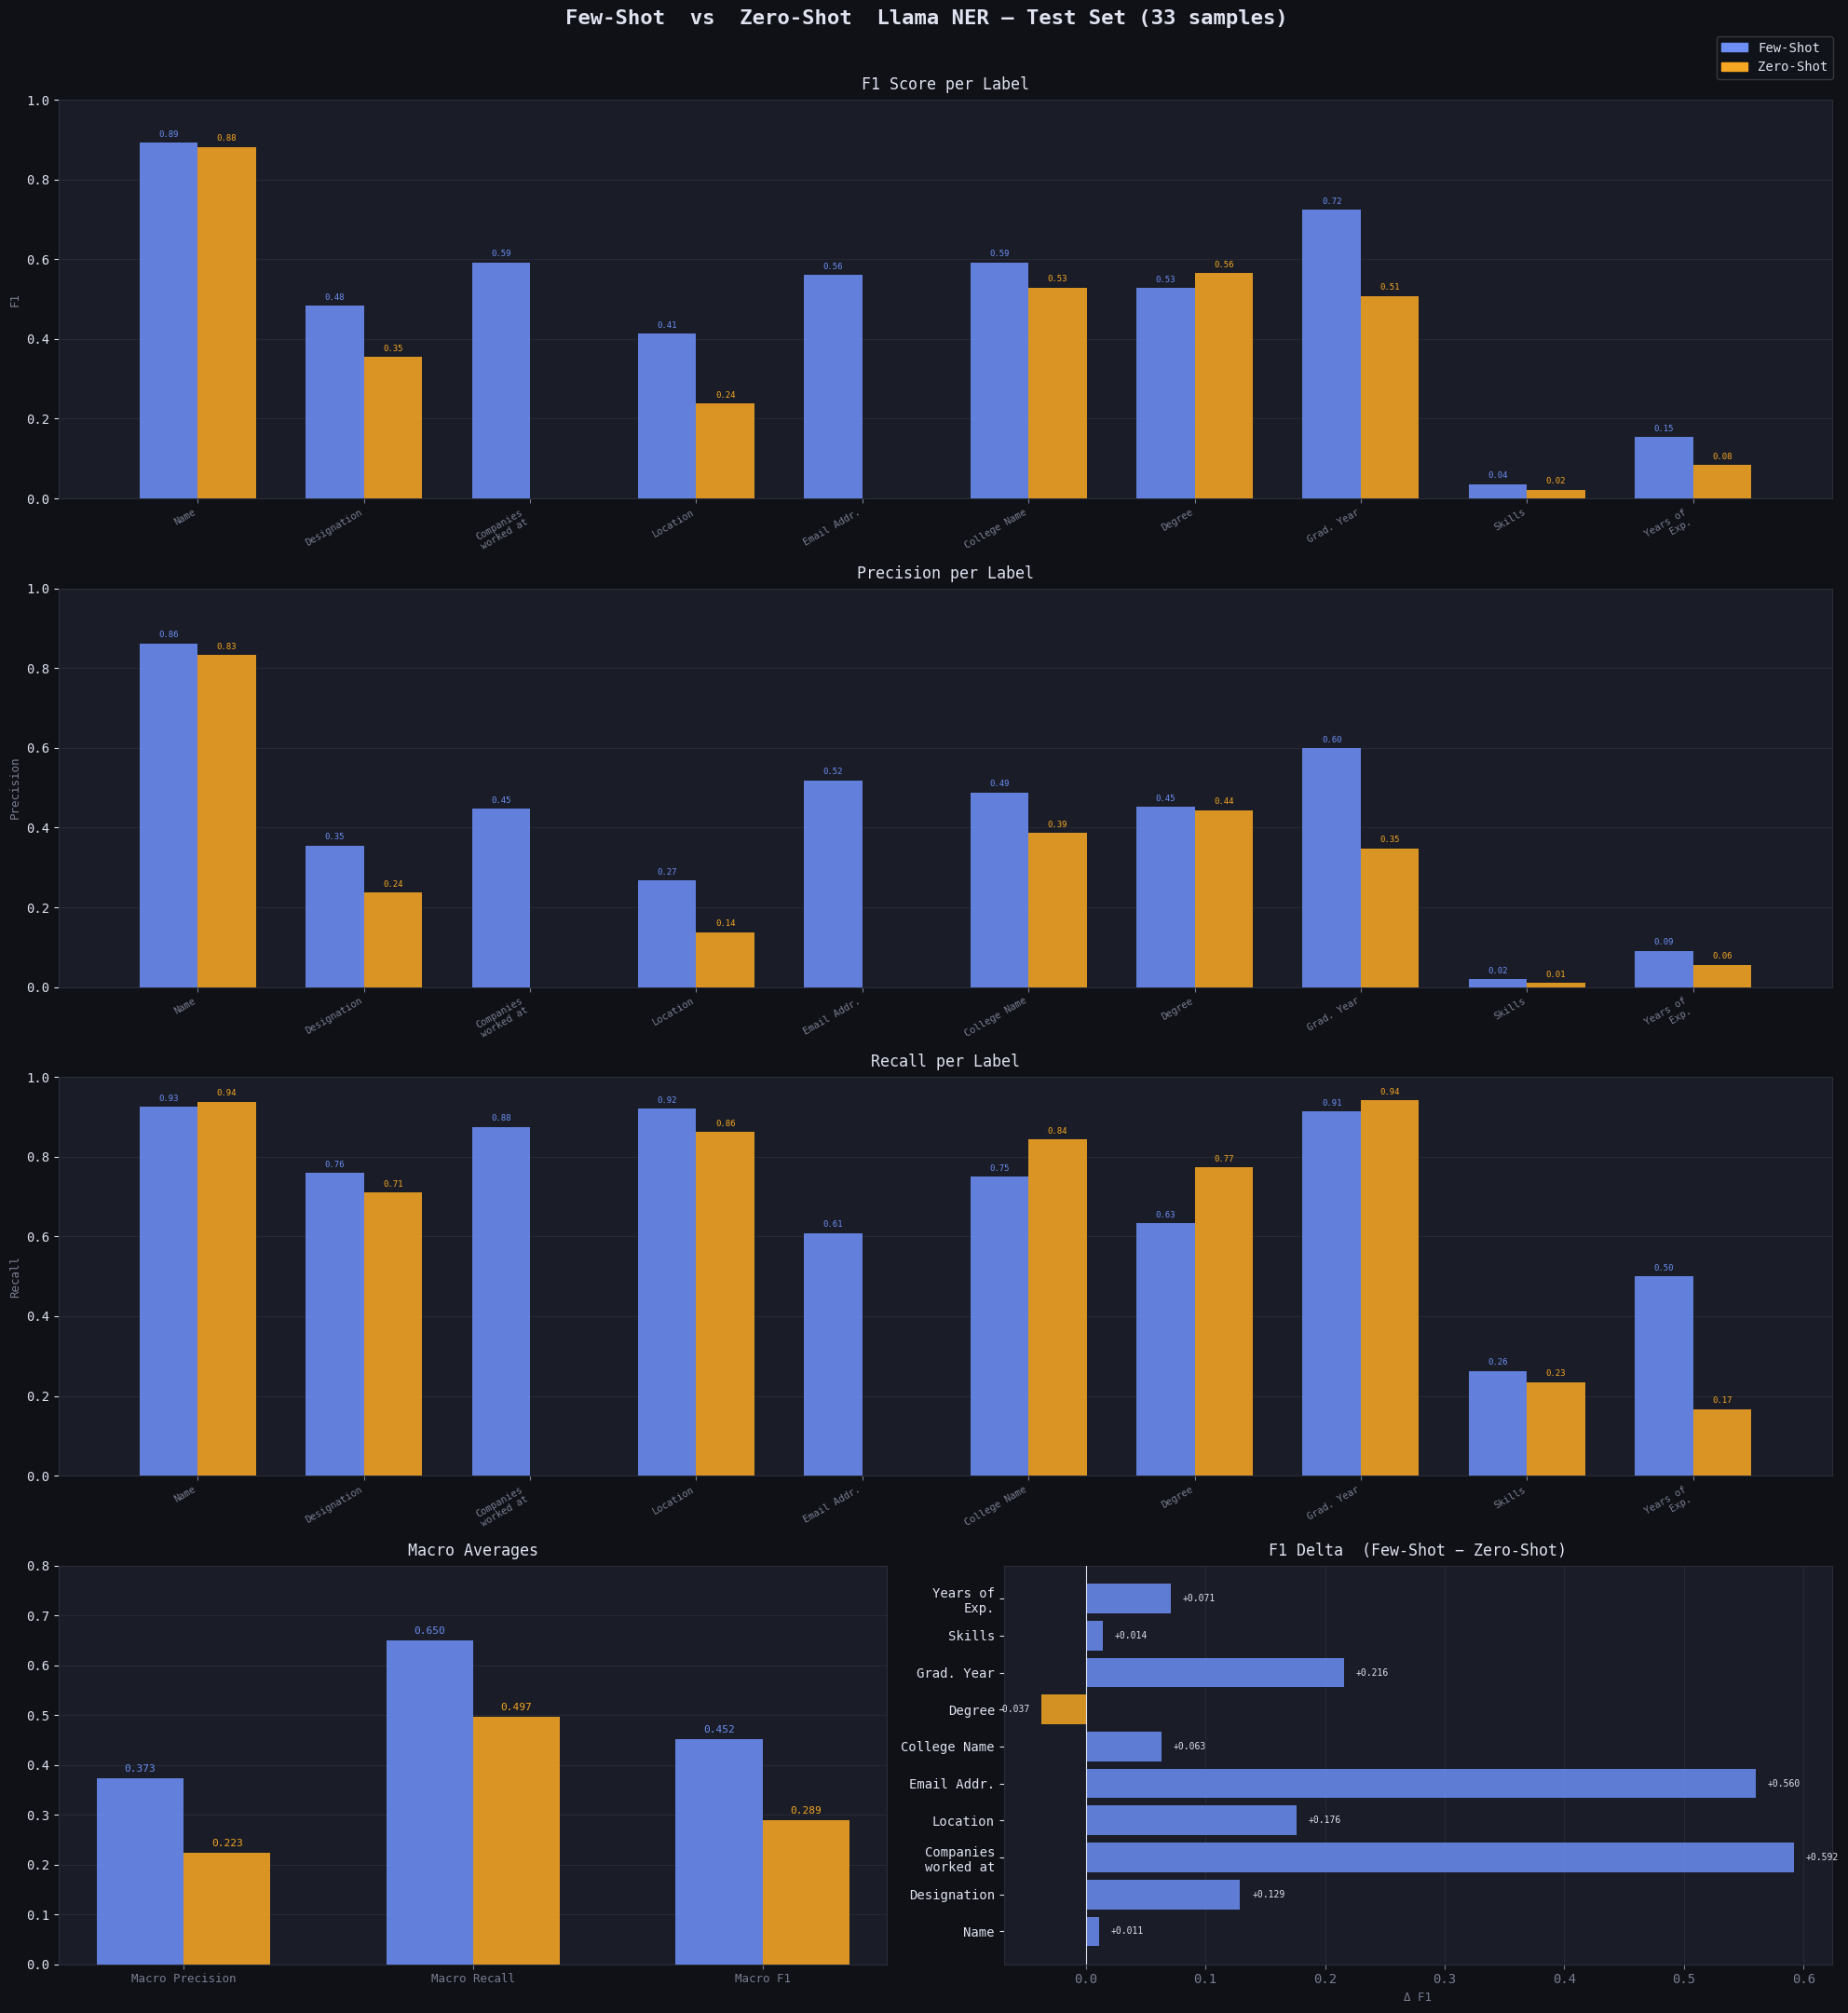

In [1]:
"""
NER Comparison: Few-Shot vs Zero-Shot Llama — Test Set (33 samples)
All data is embedded. Run with: python ner_comparison.py
Requires: matplotlib, numpy
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ──────────────────────────────────────────────
# DATA
# ──────────────────────────────────────────────

labels = [
    "Name",
    "Designation",
    "Companies worked at",
    "Location",
    "Email Address",
    "College Name",
    "Degree",
    "Graduation Year",
    "Skills",
    "Years of Experience",
]

few_shot = {
    "TP": [25, 22, 21, 23, 14, 21, 19, 21, 10, 1],
    "FP": [4,  40, 26, 63, 13, 22, 23, 14, 512, 10],
    "FN": [2,   7,  3,  2,  9,  7, 11,  2,  28,  1],
    "Precision": [0.862, 0.355, 0.447, 0.267, 0.519, 0.488, 0.452, 0.600, 0.019, 0.091],
    "Recall":    [0.926, 0.759, 0.875, 0.920, 0.609, 0.750, 0.633, 0.913, 0.263, 0.500],
    "F1":        [0.893, 0.484, 0.592, 0.414, 0.560, 0.592, 0.528, 0.724, 0.036, 0.154],
    "Macro_F1":  0.452,
    "Micro_F1":  0.299,
    "Macro_Precision": 0.373,
    "Macro_Recall":    0.650,
}

zero_shot = {
    "TP": [30, 22,  0, 25,  0, 27, 24, 16,  8,  1],
    "FP": [6,  71,  0, 156, 1, 43, 30, 30, 694, 17],
    "FN": [2,   9, 26,  4, 24,  5,  7,  1,  26,  5],
    "Precision": [0.833, 0.237, 0.000, 0.138, 0.000, 0.386, 0.444, 0.348, 0.011, 0.056],
    "Recall":    [0.938, 0.710, 0.000, 0.862, 0.000, 0.844, 0.774, 0.941, 0.235, 0.167],
    "F1":        [0.882, 0.355, 0.000, 0.238, 0.000, 0.529, 0.565, 0.508, 0.022, 0.083],
    "Macro_F1":  0.289,
    "Micro_F1":  None,  # not reported
    "Macro_Precision": 0.223,
    "Macro_Recall":    0.497,
}

# ──────────────────────────────────────────────
# STYLE
# ──────────────────────────────────────────────

BG        = "#0F1117"
PANEL     = "#1A1D27"
FEW_COLOR = "#6C8EF5"   # soft blue  — few-shot
ZER_COLOR = "#F5A623"   # amber      — zero-shot
GRID_CLR  = "#2A2D3A"
TEXT_CLR  = "#E0E2F0"
MUTED     = "#7A7D90"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    GRID_CLR,
    "axes.labelcolor":   TEXT_CLR,
    "axes.titlecolor":   TEXT_CLR,
    "xtick.color":       MUTED,
    "ytick.color":       TEXT_CLR,
    "text.color":        TEXT_CLR,
    "grid.color":        GRID_CLR,
    "grid.linewidth":    0.6,
    "font.family":       "monospace",
})

x      = np.arange(len(labels))
width  = 0.35
short  = [l.replace("Companies worked at", "Companies\nworked at")
           .replace("Years of Experience", "Years of\nExp.")
           .replace("Graduation Year", "Grad. Year")
           .replace("Email Address", "Email Addr.")
           .replace("College Name", "College Name")
           for l in labels]

fig = plt.figure(figsize=(20, 22), facecolor=BG)
fig.suptitle(
    "Few-Shot  vs  Zero-Shot  Llama NER — Test Set (33 samples)",
    fontsize=16, fontweight="bold", color=TEXT_CLR, y=0.98
)

# ──────────────────────────────────────────────
# HELPER
# ──────────────────────────────────────────────

def bar_chart(ax, fs_vals, zs_vals, title, ylabel="", ylim=(0, 1)):
    b1 = ax.bar(x - width/2, fs_vals, width, color=FEW_COLOR, alpha=0.88, zorder=3)
    b2 = ax.bar(x + width/2, zs_vals, width, color=ZER_COLOR, alpha=0.88, zorder=3)
    ax.set_title(title, fontsize=12, pad=8)
    ax.set_ylabel(ylabel, fontsize=9, color=MUTED)
    ax.set_xticks(x)
    ax.set_xticklabels(short, fontsize=7.5, rotation=30, ha="right")
    ax.set_ylim(*ylim)
    ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)
    # value labels on bars
    for bar in b1:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f"{h:.2f}", ha="center", va="bottom",
                    fontsize=6.5, color=FEW_COLOR)
    for bar in b2:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f"{h:.2f}", ha="center", va="bottom",
                    fontsize=6.5, color=ZER_COLOR)
    return b1, b2

# ──────────────────────────────────────────────
# PLOT 1 — F1 per label
# ──────────────────────────────────────────────
ax1 = fig.add_subplot(4, 1, 1)
bar_chart(ax1, few_shot["F1"], zero_shot["F1"], "F1 Score per Label", "F1")

# ──────────────────────────────────────────────
# PLOT 2 — Precision per label
# ──────────────────────────────────────────────
ax2 = fig.add_subplot(4, 1, 2)
bar_chart(ax2, few_shot["Precision"], zero_shot["Precision"],
          "Precision per Label", "Precision")

# ──────────────────────────────────────────────
# PLOT 3 — Recall per label
# ──────────────────────────────────────────────
ax3 = fig.add_subplot(4, 1, 3)
bar_chart(ax3, few_shot["Recall"], zero_shot["Recall"],
          "Recall per Label", "Recall")

# ──────────────────────────────────────────────
# PLOT 4 — Macro averages + delta table
# ──────────────────────────────────────────────
ax4 = fig.add_subplot(4, 2, 7)

metrics     = ["Macro Precision", "Macro Recall", "Macro F1"]
fs_macro    = [few_shot["Macro_Precision"], few_shot["Macro_Recall"], few_shot["Macro_F1"]]
zs_macro    = [zero_shot["Macro_Precision"], zero_shot["Macro_Recall"], zero_shot["Macro_F1"]]
xm          = np.arange(len(metrics))
wm          = 0.30

b1 = ax4.bar(xm - wm/2, fs_macro, wm, color=FEW_COLOR, alpha=0.88, zorder=3)
b2 = ax4.bar(xm + wm/2, zs_macro, wm, color=ZER_COLOR, alpha=0.88, zorder=3)

for bar, val in zip(b1, fs_macro):
    ax4.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f"{val:.3f}", ha="center", va="bottom", fontsize=8, color=FEW_COLOR)
for bar, val in zip(b2, zs_macro):
    ax4.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f"{val:.3f}", ha="center", va="bottom", fontsize=8, color=ZER_COLOR)

ax4.set_title("Macro Averages", fontsize=12, pad=8)
ax4.set_xticks(xm)
ax4.set_xticklabels(metrics, fontsize=9)
ax4.set_ylim(0, 0.8)
ax4.yaxis.grid(True, zorder=0)
ax4.set_axisbelow(True)

# ──────────────────────────────────────────────
# PLOT 5 — Delta heatmap (F1 few – zero)
# ──────────────────────────────────────────────
ax5 = fig.add_subplot(4, 2, 8)

deltas   = [f - z for f, z in zip(few_shot["F1"], zero_shot["F1"])]
colors   = [FEW_COLOR if d >= 0 else ZER_COLOR for d in deltas]
alphas   = [min(0.9, 0.35 + abs(d)) for d in deltas]

bars = ax5.barh(short, deltas, color=colors, alpha=0.85, zorder=3)
ax5.axvline(0, color=TEXT_CLR, linewidth=0.8, zorder=4)
for bar, d in zip(bars, deltas):
    ax5.text(d + (0.01 if d >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
             f"{d:+.3f}", va="center",
             ha="left" if d >= 0 else "right",
             fontsize=7, color=TEXT_CLR)
ax5.set_title("F1 Delta  (Few-Shot − Zero-Shot)", fontsize=12, pad=8)
ax5.set_xlabel("Δ F1", fontsize=9, color=MUTED)
ax5.xaxis.grid(True, zorder=0)
ax5.set_axisbelow(True)

# ──────────────────────────────────────────────
# LEGEND
# ──────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=FEW_COLOR, label="Few-Shot"),
    mpatches.Patch(color=ZER_COLOR, label="Zero-Shot"),
]
fig.legend(handles=legend_handles, loc="upper right",
           fontsize=10, framealpha=0.2,
           bbox_to_anchor=(0.99, 0.97))

plt.tight_layout(rect=[0, 0, 1, 0.97])
out = "ner_comparison.png"
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=BG)
print(f"Saved → {out}")
plt.show()